<center><span style="font-size:40px;"><b>NUTS vs HMC on GAUSSIAN 250D POSTERIOR</b></span></center>

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt   # backend symbolic math (used inside PyMC models)

import matplotlib.pyplot as plt
import time

from scipy.stats import wishart
from scipy.linalg import solve_triangular

from ucimlrepo import fetch_ucirepo # to load datasets from the UCI ML Repository

import xarray as xr  # Imported to handle multi-dimensional tracking safely

from tqdm.notebook import tqdm

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


---

### CHOOSE WHAT TO COMPUTE IN THIS NOTEBOOK

In [2]:
# choose either "computation" or "from_saved_file"

obtaining_precision_matrix = "from_saved_file"

# ========== NUTS ==============
obtaining_mu_true_nuts = "from_saved_file"
obtaining_experiments_results_nuts = "from_saved_file" 

# ========== HMC ===============
# obtaining_mu_true_hmc = "from_saved_file"
obtaining_experiments_results_hmc = "from_saved_file" 

---

### PRECISION MATRIX

In [3]:
D = 250        # number of dimensions
N = 1000       # number of draws
dof = 250      # number of degrees of freedom for precision matrix


if obtaining_precision_matrix == "computation":

    # Set random seed for reproducibility
    rng = np.random.default_rng(12345)

    # But if we just treat the distribution as our posterior, we can simply draw from it with pyMC
    A = wishart.rvs(df=dof, scale=np.eye(D), random_state=rng).astype(np.float64)
    # Saving precision matrix to file for reproducibility
    np.save("PrecisionMatrix.npy", A, allow_pickle=True)

elif obtaining_precision_matrix == "from_saved_file":
    A = np.load("PrecisionMatrix.npy")

### MCSE FUNCTION

In [4]:
# Monte Carlo Standard Error (MCSE) on realized mean acceptance rate
def mcse_batch_means(x, batch_size=None, min_batches=20):
    """
    We split the sinle input chain into m batches
    Compute the mean of each batch
    Treats those batch means as approximately independent
    Estimates variance from them
    """
    x = np.asarray(x, dtype=float).ravel()   # now this is a 1D array
    n = x.size                               # number of samples
    
    if batch_size is None:
        batch_size = int(np.sqrt(n))
    batch_size = max(1, int(batch_size))
    m = n // batch_size                      # m = number of batches
    
    if m < min_batches:   
        batch_size = max(1, n // min_batches) # ensures at least min_batches (default 20)
        m = n // batch_size
        
    if m < 2:  # safety check
        raise ValueError(f"Not enough data: n={n}, batch_size={batch_size}, batches={m}")

    # discards leftover samples so reshape works cleanly
    n_used = m * batch_size
    x_used = x[:n_used]
    
    # BATCH MEANS:
    batch_means = x_used.reshape(m, batch_size).mean(axis=1)   # we obtain m means
    mcse = batch_means.std(ddof=1) / np.sqrt(m)                # computes mcse with independent approx
    
    return mcse

### pyMC MODEL DEFINITION

In [5]:
# ======================= MODEL DEFINITION =================
# We define the model logic inside a function so we can reuse it for both baseline and experiment runs
def create_Gauss_model(dimension, precision):
    with pm.Model() as model:  
        theta = pm.MvNormal("theta", mu=np.zeros(dimension), tau=precision, shape=dimension)
    return model


my_model = create_Gauss_model(D, A)

---

---

---

---

<center><span style="font-size:50px;"><b>NUTS</b></span></center>

### NUTS FUNCTION

In [6]:
def acc_rate_sweep_gauss( model, acceptance_rate_list, repetitions, sample_dict ):
    
    results = pd.DataFrame(columns=["Group", "Diff", "MCSE", "Min", "Mean", "Bulk Min", "Bulk Mean", "Grad Evals"])
    seed_offset = 0
    bins = np.arange(0, sample_dict["max_treedepth"]+2, 1) - 0.5
    # Store the counts of the reached depth: one row for each value of the target acceptance and one column for each frequency
    depth_counts = np.zeros(shape=(len(acceptance_rate_list), len(bins)-1 ))
    
    for i, target_accept in (enumerate(acceptance_rate_list)):
        print(f"Running Set {i+1}/{len(acceptance_rate_list)}")
        for _ in tqdm(range(repetitions)):
            with model:
                idata = pm.sample(  
                draws = sample_dict["draws"],     # number of posterior samples (after warmup)
                tune = sample_dict["tune"],      # number of warmup steps
                chains = sample_dict["chains"], 
                target_accept = target_accept,
                random_seed = sample_dict["start_seed"] + seed_offset,     # different seed for each run
                max_treedepth = sample_dict["max_treedepth"],
                progressbar = False,    # disable progress bar
                quiet = True,           # suppress sampler messages
                nuts_sampler = "pymc",  # use PyMC's NUTS implementation        
            )
            seed_offset += 1

            # extract acceptance rates and put them together for the same experiment
            acceptance = idata.sample_stats["acceptance_rate"].to_numpy()  
            h_chain = acceptance.reshape(-1,).mean()     # mean acceptance per experiment
            diff_chain = h_chain - target_accept  # deviation from target δ exeriment
            
            mcse = np.zeros(sample_dict["chains"]) # initialize MCSE array (per chain)
            # Loop over chains (Only for MCSE/Acceptance stats)
            for c in range(sample_dict["chains"]): 
                mcse[c] = mcse_batch_means(acceptance[c])  # estimate MCSE of mean acceptance for each chain

            # 2. Combine the MCSE error bars properly for independent chains
            combined_mcse = np.sqrt( (mcse**2).sum() )/ sample_dict["chains"]

            # ============== Computing ESS and Gradient Evaluations =============
    
            # Get the number of steps (POST WARM UP) 
            n_steps = idata.sample_stats["n_steps"].to_numpy()   # shape: (chains, draws)        
            
            # In the paper, ESS is normalized by the TOTAL amount of gradient evaluations across all samples
            total_grad_evals = n_steps.sum()  # Scalar: total gradient evaluations across all chains & draws

            # Like in the paper
            # 1. Compute Mean ESS
            ess_mean = az.ess(idata, method="mean")
            
            # 2. Compute Second Central Moment ESS
            # FIX: Keep data as an xarray Dataset so ArviZ preserves named dimensions for the 250D theta
            sq_diff_ds = xr.Dataset({
                "theta": (idata.posterior["theta"] - mu_true_theta)**2
            })
            ess_var = az.ess(sq_diff_ds, method="mean")

            # 3. Take the minimum between mean and variance for each dimension
            # Both ess_mean and ess_var are now clean xarray Datasets, so .values extracts the array properly
            ess_theta_min = np.minimum(ess_mean["theta"].values, ess_var["theta"].values)

            # Normalize by the total gradient evaluations
            ess_per_grad_theta = ess_theta_min / total_grad_evals

            # Final Aggregation across dimensions to get a single number
            # Average across dimensions
            mean_ess_grad_theta = np.mean(ess_per_grad_theta)
            ESS_PER_GRAD_MEAN = mean_ess_grad_theta

            # Strict paper methodology: take the absolute worst-case dimension
            ESS_PER_GRAD_MIN = np.min(ess_per_grad_theta)

             # Compute Bulk ESS natively
            ess_bulk = az.ess(idata, method="bulk")

            ess_theta_bulk = ess_bulk["theta"].values

            ess_per_grad_theta_bulk = ess_theta_bulk / total_grad_evals 

            # Final Aggregation across dimensions to get a single number
            # Average across dimensions
            mean_ess_grad_theta_bulk = np.mean(ess_per_grad_theta_bulk)
            ESS_PER_GRAD_MEAN_bulk = mean_ess_grad_theta_bulk

            # Strict paper methodology: take the absolute worst-case dimension
            ESS_PER_GRAD_MIN_bulk = np.min(ess_per_grad_theta_bulk)

            # Save results to dataframe
            tmp= pd.DataFrame({"Group" : i,
                            "Diff"  : diff_chain,
                            "MCSE"  : combined_mcse,
                            "Min"   : ESS_PER_GRAD_MIN,
                            "Mean"  : ESS_PER_GRAD_MEAN,
                            "Bulk Min": ESS_PER_GRAD_MIN_bulk,
                            "Bulk Mean": ESS_PER_GRAD_MEAN_bulk,
                            "Grad Evals": total_grad_evals
                           }, index = [0])
            
            results = pd.concat([results, tmp], ignore_index=True)

            depth = idata.sample_stats["tree_depth"].to_numpy().ravel()  # flatten chains+draws
            curr_counts, egdes = np.histogram(depth, bins = bins)
            depth_counts[i,:] += curr_counts
            
    return results, depth_counts

### MU TRUE NUTS SEARCH

In [7]:
if obtaining_mu_true_nuts == "computation":
    # ======================= BASELINE RUN (50k Samples) =================
    
    print("Running baseline 50,000 samples to compute mu_true for the second central moment...")
    with my_model:
        baseline_idata = pm.sample(
            draws=50000, 
            tune=1000, 
            chains=1,                       # The paper runs a single long chain for the baseline
            target_accept=0.5,              # delta = 0.5 as specified in the paper
            random_seed=42,
            nuts_sampler="pymc",
            progressbar=True,
            max_treedepth = 14
        )
    # Extract the highly precise true means (mu_true)
    mu_true_theta = baseline_idata.posterior["theta"].mean(dim=["chain", "draw"]).values
    print("Baseline complete. mu_true calculated.")
    np.save("true_theta_Gauss.npy", mu_true_theta)



elif obtaining_mu_true_nuts == "from_saved_file":
    mu_true_theta = np.load("true_theta_Gauss.npy")

### NUTS EXPERIMENTS RUN

In [8]:
delta_list = np.linspace(0.25, 0.95, 15)
reps = 10
warmup = 1000
sample_settings = {"draws": N,
                   "tune" : warmup,
                   "chains": 4,
                   "start_seed": 2026,
                   "max_treedepth": 14
                  }

if obtaining_experiments_results_nuts == "computation":

    # ============= RUNNING EXPERIMENTS ======================
    start_time = time.perf_counter()   # debug
    
    df, depths = acc_rate_sweep_gauss(my_model, delta_list, reps, sample_settings)
    
    
    # DEBUG:
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Time elapsed: {elapsed_time:.4f} seconds")

    # saving results:
    df.to_pickle("NUTS_GAUSS.pkl")
    np.save("tree_depths_GAUSS.npy", depths)



elif obtaining_experiments_results_nuts == "from_saved_file":
    df = pd.read_pickle("NUTS_GAUSS.pkl")
    depths = np.load("tree_depths_GAUSS.npy")

In [9]:
# DEBUG (to be changed manually each time)
print(f"Time for last computing: {14896.6280/60/60:.3f} hours")

Time for last computing: 4.138 hours


In [10]:
df.head(15)

,Group,Diff,MCSE,Min,Mean,Bulk Min,Bulk Mean,Grad Evals
0,0,-0.102822,0.002546,0.000003,0.000019,0.000004,0.000068,2370262.0
1,0,-0.076628,0.002697,0.000004,0.000027,0.000004,0.00015,2163707.0
2,0,-0.032308,0.002772,0.000172,0.000277,0.000173,0.00028,3079616.0
3,0,-0.08673,0.002578,0.000003,0.000011,0.000003,0.000045,2172541.0
4,0,-0.139115,0.001984,0.000003,0.000014,0.000004,0.000063,2062070.0
5,0,-0.014234,0.003145,0.000124,0.000214,0.000124,0.000217,3007712.0
6,0,-0.008656,0.002811,0.000168,0.000273,0.000169,0.000278,3071456.0
7,0,-0.000227,0.002832,0.000177,0.000275,0.000178,0.00028,3002528.0
8,0,0.058381,0.003096,0.000162,0.000265,0.000162,0.000269,3095648.0
9,0,-0.085604,0.002038,0.000002,0.000011,0.000003,0.000049,2256866.0


# RESULTS VISUALIZATION

### DISTANCE FROM TARGET VALUE $\delta$

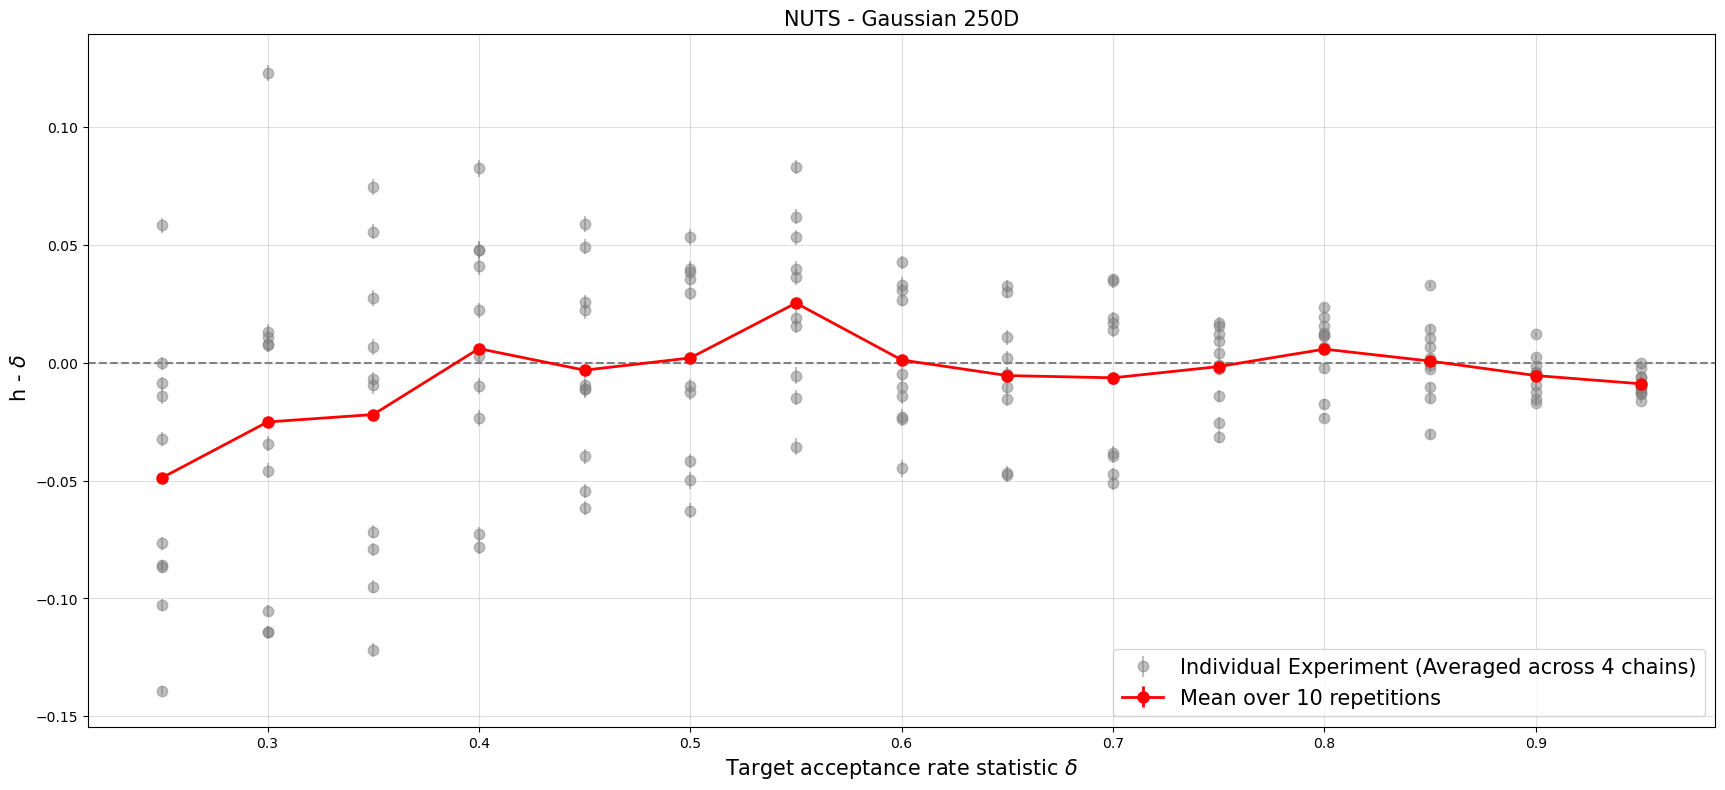

In [29]:
x_in_graph = [delta_list[i] for i in df["Group"].values]

# Plotting the single-experiment representation
fig, ax = plt.subplots(figsize=(21,9))

# Plot with errorbars using the combined metrics
ax.errorbar(
    x = x_in_graph, 
    y = df["Diff"], 
    yerr = df["MCSE"], 
    ls="None", 
    marker=".", 
    ms=15, 
    label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
    color="gray",
    alpha = 0.5
)

ax.errorbar(x = delta_list,
            y = df.groupby(by="Group").mean()["Diff"],
            yerr = df.groupby(by="Group")["MCSE"].apply(lambda x: np.sqrt( (x**2).sum()) / reps ),
            ls = "-",
            marker = "o",
            ms = 8,
            label = f"Mean over {reps} repetitions",
            color="red",
            lw = 2
)

plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel(r" h - $\delta$", fontsize=15)
plt.title("NUTS - Gaussian 250D", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.axhline(y=0.0, ls="--", color="gray")
plt.grid(alpha=0.4)

# plt.savefig("/home/benedetto/Scrivania/INFERENCE/project/plots/gaussian_250D_target_nuts.png")

plt.show()

### ESS / Grad

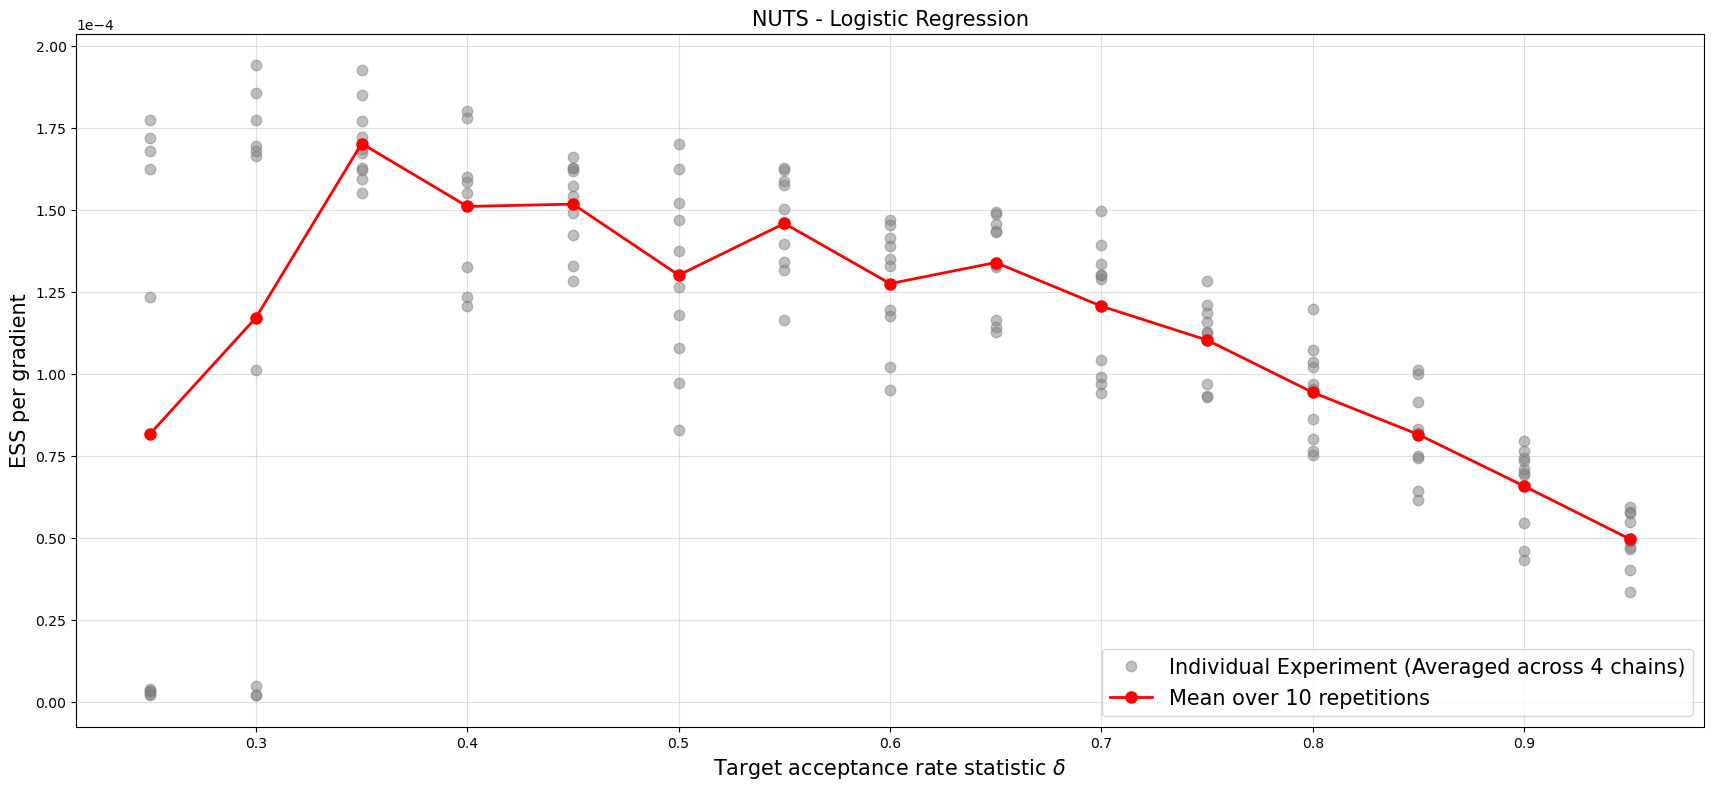

In [31]:
# Plotting the single-experiment representation
fig, ax = plt.subplots(figsize=(21,9))

# Plot with errorbars using the combined metrics
ax.plot(
    x_in_graph, 
    df["Min"], 
    ls="None", 
    marker=".", 
    ms=15, 
    label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
    color="gray",
    alpha = 0.5
)

ax.plot(delta_list,
        df.groupby(by="Group").mean()["Min"],
        ls = "-",
        marker = "o",
        ms = 8,
        label = f"Mean over {reps} repetitions",
        color="red",
        lw = 2
)

plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel("ESS per gradient", fontsize=15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.grid(alpha=0.4)

# plt.savefig("/home/benedetto/Scrivania/INFERENCE/project/plots/gaussian_250D_ess_nuts.png")


plt.show()

### TREE COUNTS

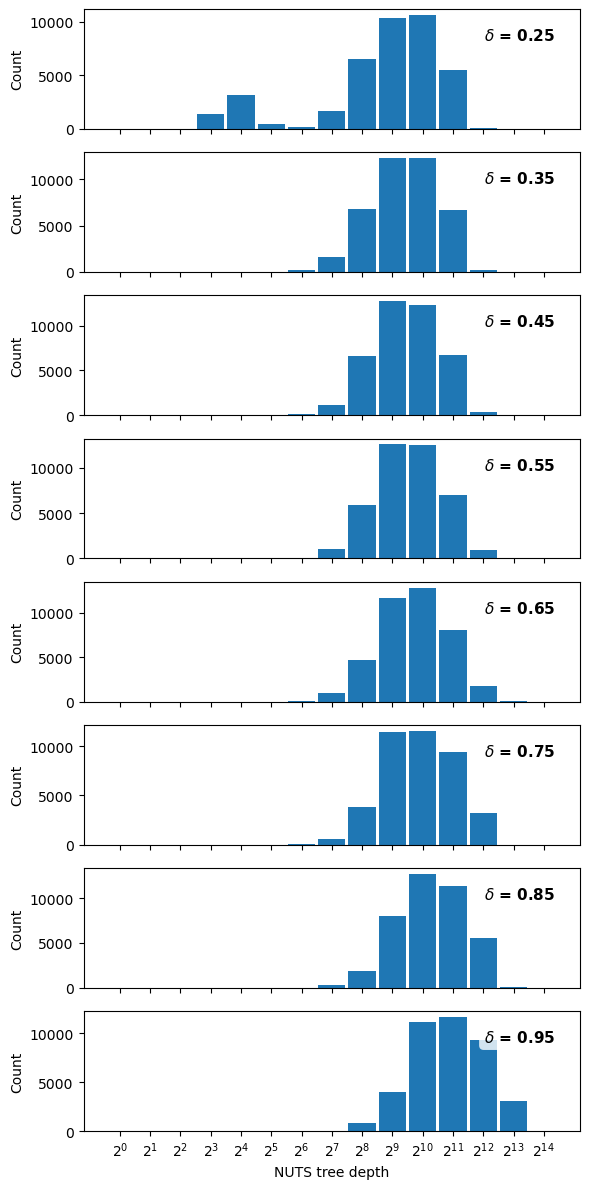

In [9]:
# Your index selection array
show_this_delta = np.arange(0, len(delta_list), 2, dtype="int")

# 1. Calculate number of vertical rows
n_rows = len(show_this_delta)

# 2. Create a single vertical column grid
# Each panel gets a height of 2.5 inches (adjust as you like)
fig, axes = plt.subplots(n_rows, 1, figsize=(6, 1.5 * n_rows), sharex=True)

# Handle the edge case where show_this_delta has only 1 element
if n_rows == 1:
    axes = [axes]

x_ticks = np.arange(0, sample_settings["max_treedepth"] + 1, 1)
x_labels = [fr"$2^{{{k}}}$" for k in range(sample_settings["max_treedepth"] + 1)]

# 3. Populate the vertical grid
for plot_idx, i in enumerate(show_this_delta):
    ax = axes[plot_idx]
    
    # Draw the bar chart
    ax.bar(x_ticks, depths[i], width=0.9, color="C0", edgecolor="none")
    
    # Always set ticks, but sharex=True will automatically hide labels for upper plots
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    
    # Y-Label for each specific panel
    ax.set_ylabel("Count")
    
    # Place delta text directly inside the plot panel (top right)
    ax.text(
        0.95, 0.85, 
        fr"$\delta$ = {delta_list[i]:.2f}", 
        transform=ax.transAxes, 
        horizontalalignment="right", 
        verticalalignment="top",
        fontsize=11,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none")
    )

# 4. Set the X-label only on the very last (bottom) subplot panel
axes[-1].set_xlabel("NUTS tree depth")

plt.tight_layout()
plt.savefig("./saved_plots/gauss_tree_length.png", bbox_inches='tight', dpi=300)
plt.show()

---

---

---

---

<center><span style="font-size:50px;"><b>HMC</b></span></center>

### HMC FUNCTION

In [14]:
def acc_rate_sweep_HMC( model, acceptance_rate_list, repetitions, sample_dict ):
    
    results = pd.DataFrame(columns=["Group", "Path Length", "Diff", "MCSE", "Min", "Mean", "Bulk Min", "Bulk Mean", "Grad Evals"])
    seed_offset = 0

    for path_l in sample_dict["path_length"]:
        
        print(f"------ Testing path length {path_l:.2f}------ ")
        
        for i, target_accept in (enumerate(acceptance_rate_list)):
            
            print(f"Running Set {i+1}/{len(acceptance_rate_list)}")
            
            for _ in tqdm(range(repetitions)):
                with model:
                    idata = pm.sample(  
                    draws = sample_dict["draws"],     # number of posterior samples (after warmup)
                    tune = sample_dict["tune"],      # number of warmup steps
                    chains = sample_dict["chains"],
                    # Changing from NUTS to HMC by defining the hyperparameters
                    step = pm.HamiltonianMC(target_accept = target_accept,   # acceptance probability to adapt step size toward
                                            path_length = path_l,            # total trajectory length ( lambda ≈ ε * L)
                                       ),
                    random_seed = sample_dict["start_seed"] + seed_offset,     # different seed for each run
                    progressbar = False,    # disable progress bar
                    quiet = True           # suppress sampler messages  
                )
                seed_offset += 1
    
                # extract acceptance rates and put them together for the same experiment: Here accepted is a bool for each step
                acceptance = idata.sample_stats["accepted"].to_numpy()  
                h_chain = acceptance.reshape(-1,).mean()     # mean acceptance per experiment
                diff_chain = h_chain - target_accept  # deviation from target δ exeriment
                
                mcse = np.zeros(sample_dict["chains"]) # initialize MCSE array (per chain)
                # Loop over chains (Only for MCSE/Acceptance stats)
                for c in range(sample_dict["chains"]): 
                    mcse[c] = mcse_batch_means(acceptance[c])  # estimate MCSE of mean acceptance for each chain
    
                # 2. Combine the MCSE error bars properly for independent chains
                combined_mcse = np.sqrt( (mcse**2).sum() )/ sample_dict["chains"]



                
                # ============== Computing ESS and Gradient Evaluations =============
                
                # Get the number of leapfrog steps (gradient evaluations) (POST WARM UP) 
                n_steps = idata.sample_stats["n_steps"].to_numpy()   # shape: (chains, draws)        
                
                # In the paper, ESS is normalized by the TOTAL amount of gradient evaluations
                total_grad_evals = n_steps.sum()  # scalar: total gradient evaluations across all chains & draws
                
                # ------------------------------------------------------------
                # PAPER-STYLE ESS (mean + second moment)
                # ------------------------------------------------------------
                
                # 1. Compute ESS for the mean
                ess_mean = az.ess(idata, method="mean")
                
                # 2. Compute ESS for the second central moment
                # (theta - mu_true)^2, keeping xarray structure for correct dimensions
                sq_diff_ds = xr.Dataset({
                    "theta": (idata.posterior["theta"] - mu_true_theta)**2
                })
                ess_var = az.ess(sq_diff_ds, method="mean")
                
                # 3. Take the minimum between mean and variance ESS for each dimension
                # shape: (D,)
                ess_theta_min = np.minimum(ess_mean["theta"].values, ess_var["theta"].values)
                
                # Normalize by total gradient evaluations
                ess_per_grad_theta = ess_theta_min / total_grad_evals
                
                # Final aggregation across dimensions
                # Average efficiency
                ESS_PER_GRAD_MEAN = np.mean(ess_per_grad_theta)
                # Worst-case dimension (paper metric)
                ESS_PER_GRAD_MIN = np.min(ess_per_grad_theta)
                
                
                # ------------------------------------------------------------
                # MODERN ESS (bulk ESS from ArviZ)
                # ------------------------------------------------------------
                
                ess_bulk = az.ess(idata, method="bulk")
                
                # Extract per-dimension ESS
                ess_theta_bulk = ess_bulk["theta"].values  # shape: (D,)
                
                # Normalize by total gradient evaluations
                ess_per_grad_theta_bulk = ess_theta_bulk / total_grad_evals
                
                # Final aggregation across dimensions
                # Average efficiency
                ESS_PER_GRAD_MEAN_bulk = np.mean(ess_per_grad_theta_bulk)
                # Worst-case dimension
                ESS_PER_GRAD_MIN_bulk = np.min(ess_per_grad_theta_bulk)
                
                
                # ------------------------------------------------------------
                # Save results to dataframe
                # ------------------------------------------------------------
                
                tmp = pd.DataFrame({
                    "Group"      : i,
                    "Path Length": path_l,
                    "Diff"       : diff_chain,
                    "MCSE"       : combined_mcse,
                    "Min"        : ESS_PER_GRAD_MIN,
                    "Mean"       : ESS_PER_GRAD_MEAN,
                    "Bulk Min"   : ESS_PER_GRAD_MIN_bulk,
                    "Bulk Mean"  : ESS_PER_GRAD_MEAN_bulk,
                    "Grad Evals" : total_grad_evals
                }, index=[0])
                
                results = pd.concat([results, tmp], ignore_index=True)
            
    return results

### HMC EXPERIMENT RUN

In [15]:
delta_list_HMC = np.arange(0.25, 0.95, 0.1)
path_L_for_ESS = [3.4, 5.2, 7.8, 12, 18, 27, 40]
path_L_for_h_delta = [1.5, 3.4, 7.8, 18, 40]
path_length_list_temp = np.union1d(path_L_for_ESS, path_L_for_h_delta)
path_L_external = [1.0, 2.3]  # these are the values that the paper has computed but not shown us
path_length_list = np.union1d(path_length_list_temp, path_L_external)
reps_HMC = 10                                          # number of experiments
sample_settings_HMC = { "draws": 1000,
                        "tune" : 1000,
                        "chains": 4,
                        "start_seed": 2026,
                        "path_length": path_length_list
                      }

if obtaining_experiments_results_hmc == "computation":

    # ============= RUNNING EXPERIMENTS ======================
    
    start_time = time.perf_counter()   # debug

    df_HMC = acc_rate_sweep_HMC( my_model, delta_list_HMC, reps_HMC, sample_settings_HMC )
    
    
    # DEBUG:
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Time elapsed: {elapsed_time:.4f} seconds")

    # saving results:
    df_HMC.to_pickle("HMC_GAUSS.pkl")


elif obtaining_experiments_results_hmc == "from_saved_file":
    df_HMC = pd.read_pickle("HMC_GAUSS.pkl")

In [16]:
# DEBUG (to be changed manually each time)
print(f"Time for last computing: {23534.8312/60/60:.3f} hours")

Time for last computing: 6.537 hours


In [17]:
df_HMC.head(15)

,Group,Path Length,Diff,MCSE,Min,Mean,Bulk Min,Bulk Mean,Grad Evals
0,0,1.0,-0.06475,0.009018,0.00064,0.000714,0.000685,0.000805,6358
1,0,1.0,-0.1075,0.008542,0.000654,0.000716,0.000708,0.00081,6203
2,0,1.0,-0.1005,0.007453,0.00068,0.00078,0.000732,0.00087,6053
3,0,1.0,-0.0825,0.008474,0.00064,0.000728,0.000682,0.000811,6367
4,0,1.0,-0.05625,0.009053,0.000629,0.000749,0.000679,0.000838,6508
5,0,1.0,-0.092,0.0087,0.000605,0.000682,0.000649,0.000754,6713
6,0,1.0,-0.03275,0.009389,0.000629,0.000722,0.000683,0.000814,6464
7,0,1.0,-0.111,0.0075,0.000655,0.000738,0.000711,0.000831,6209
8,0,1.0,-0.1245,0.008039,0.000631,0.000703,0.000669,0.000789,6437
9,0,1.0,-0.037,0.009403,0.000634,0.000742,0.000674,0.000823,6404


### ACCEPTANCE RATE

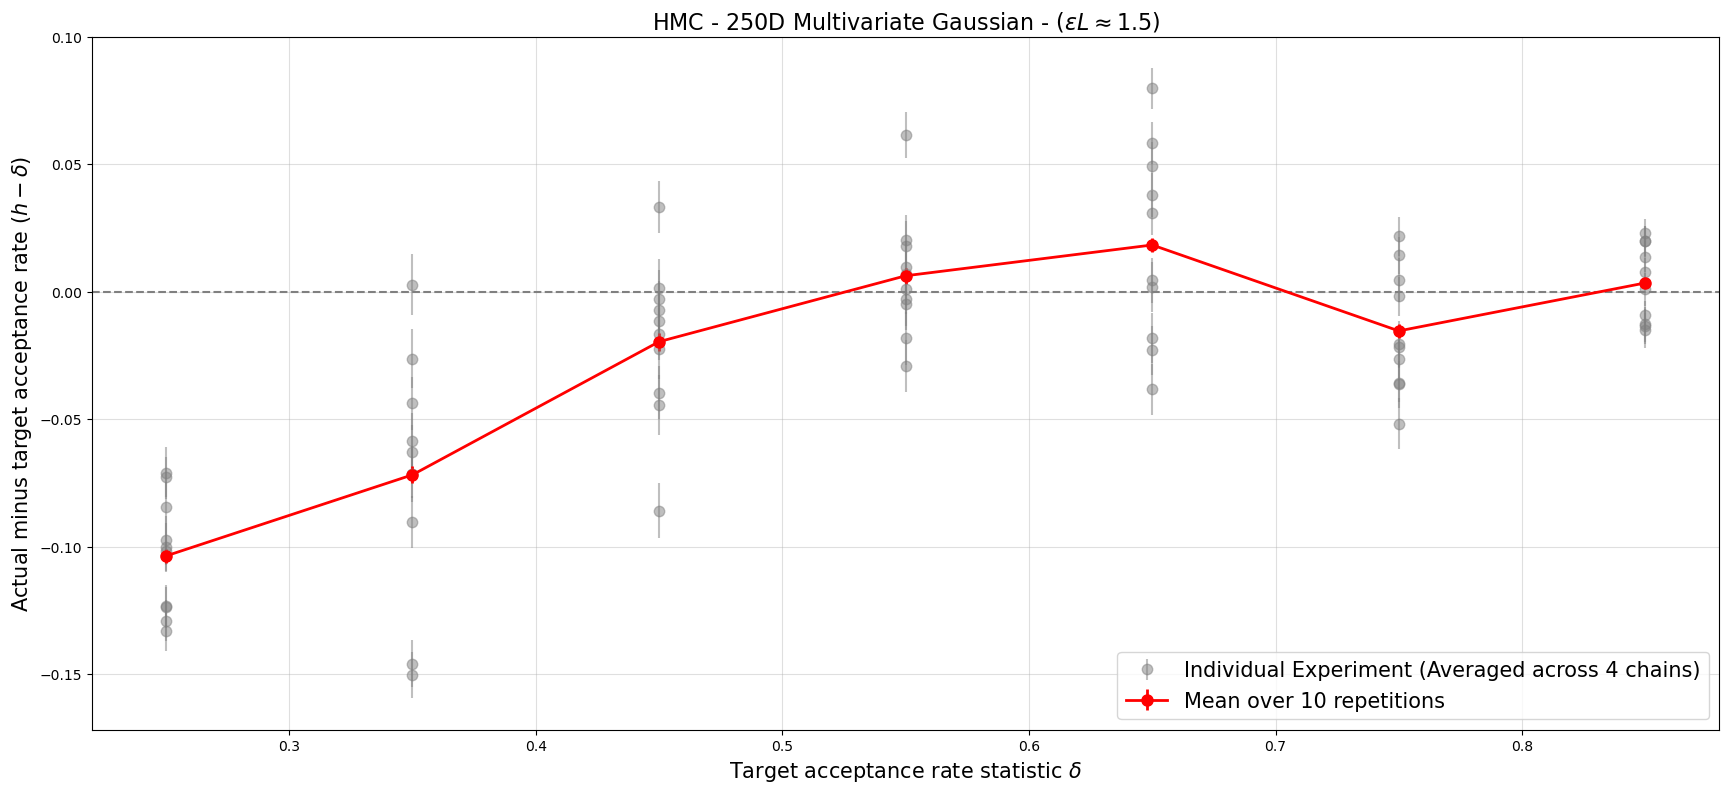

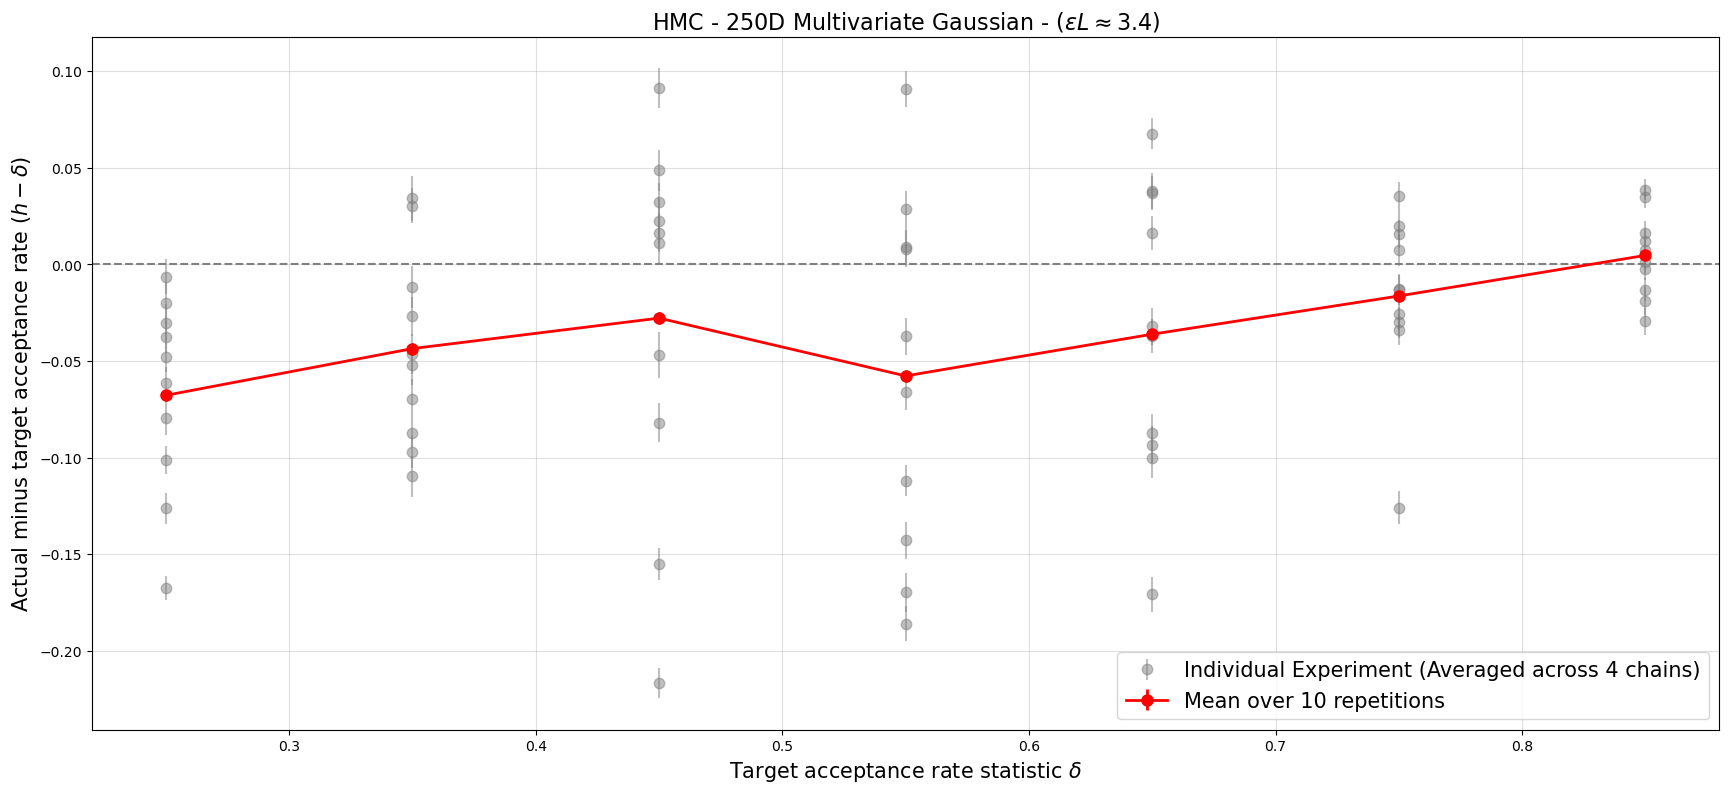

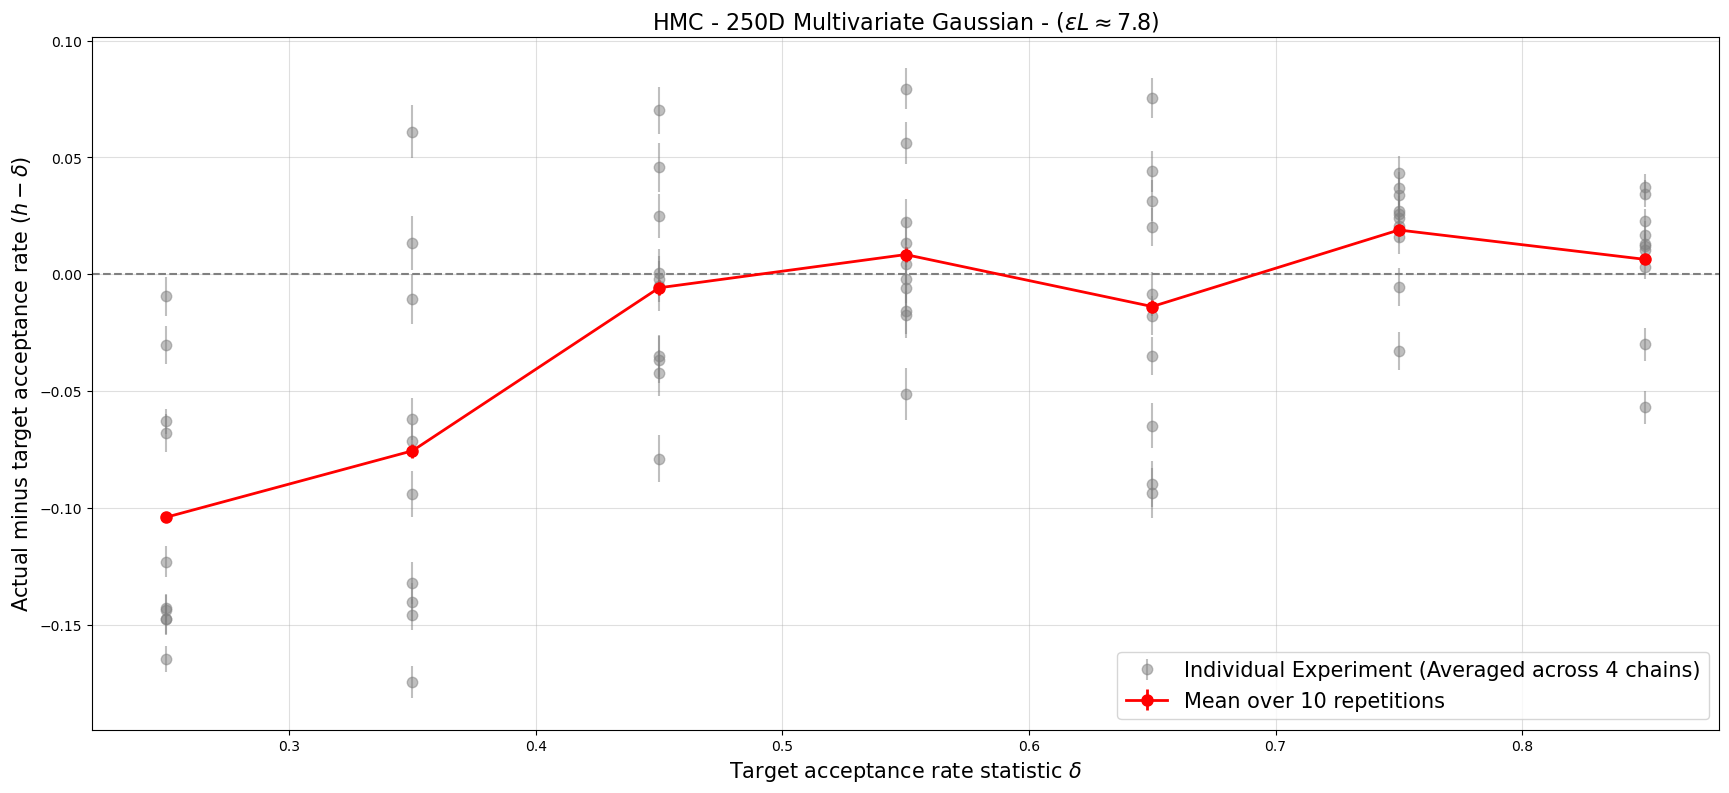

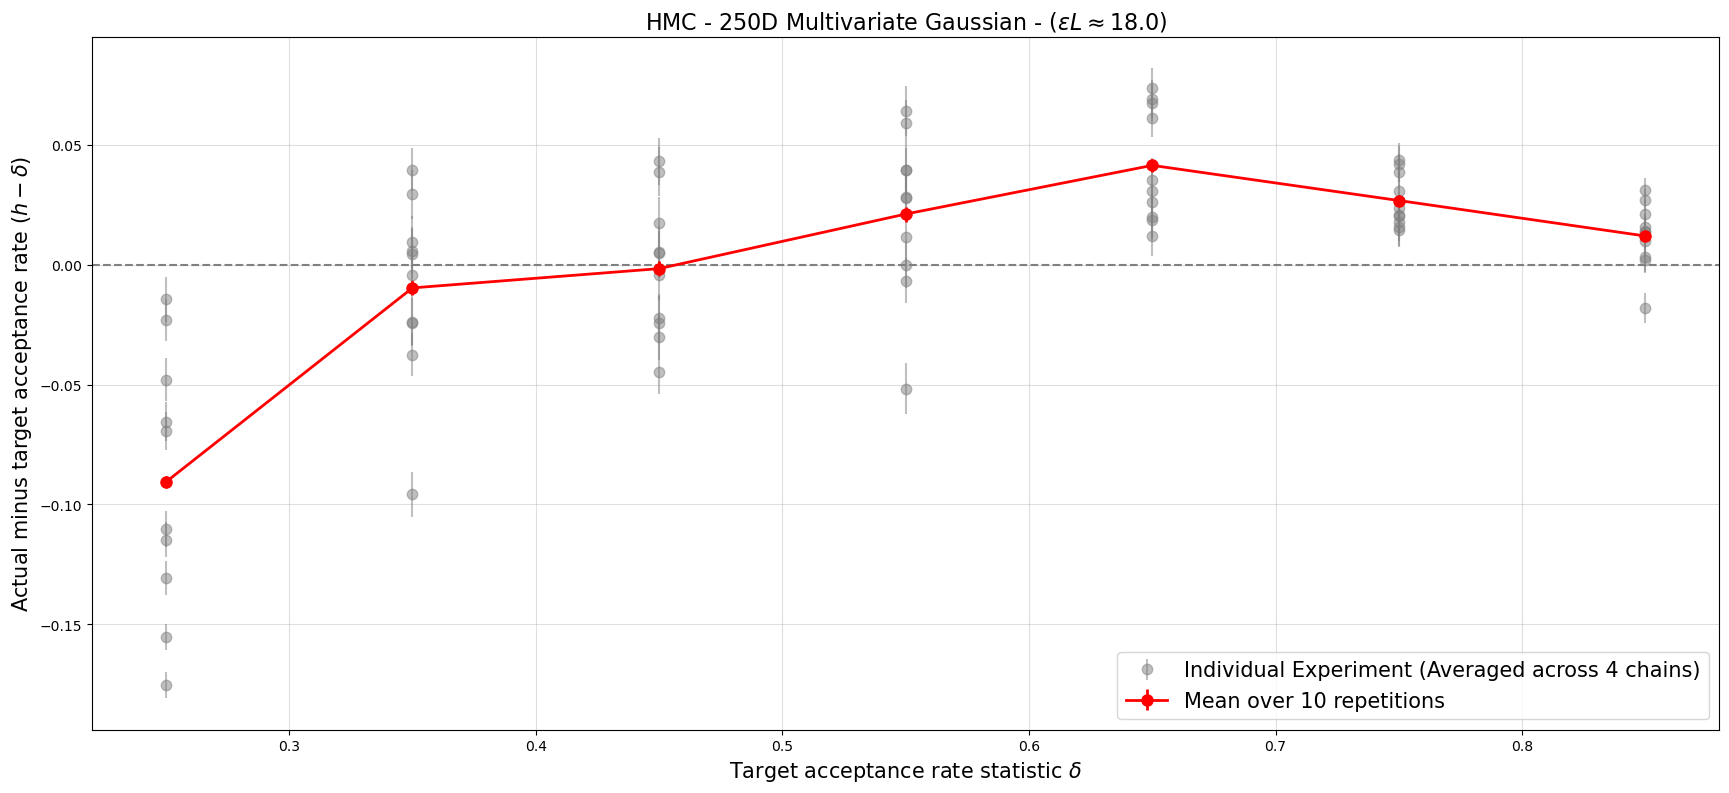

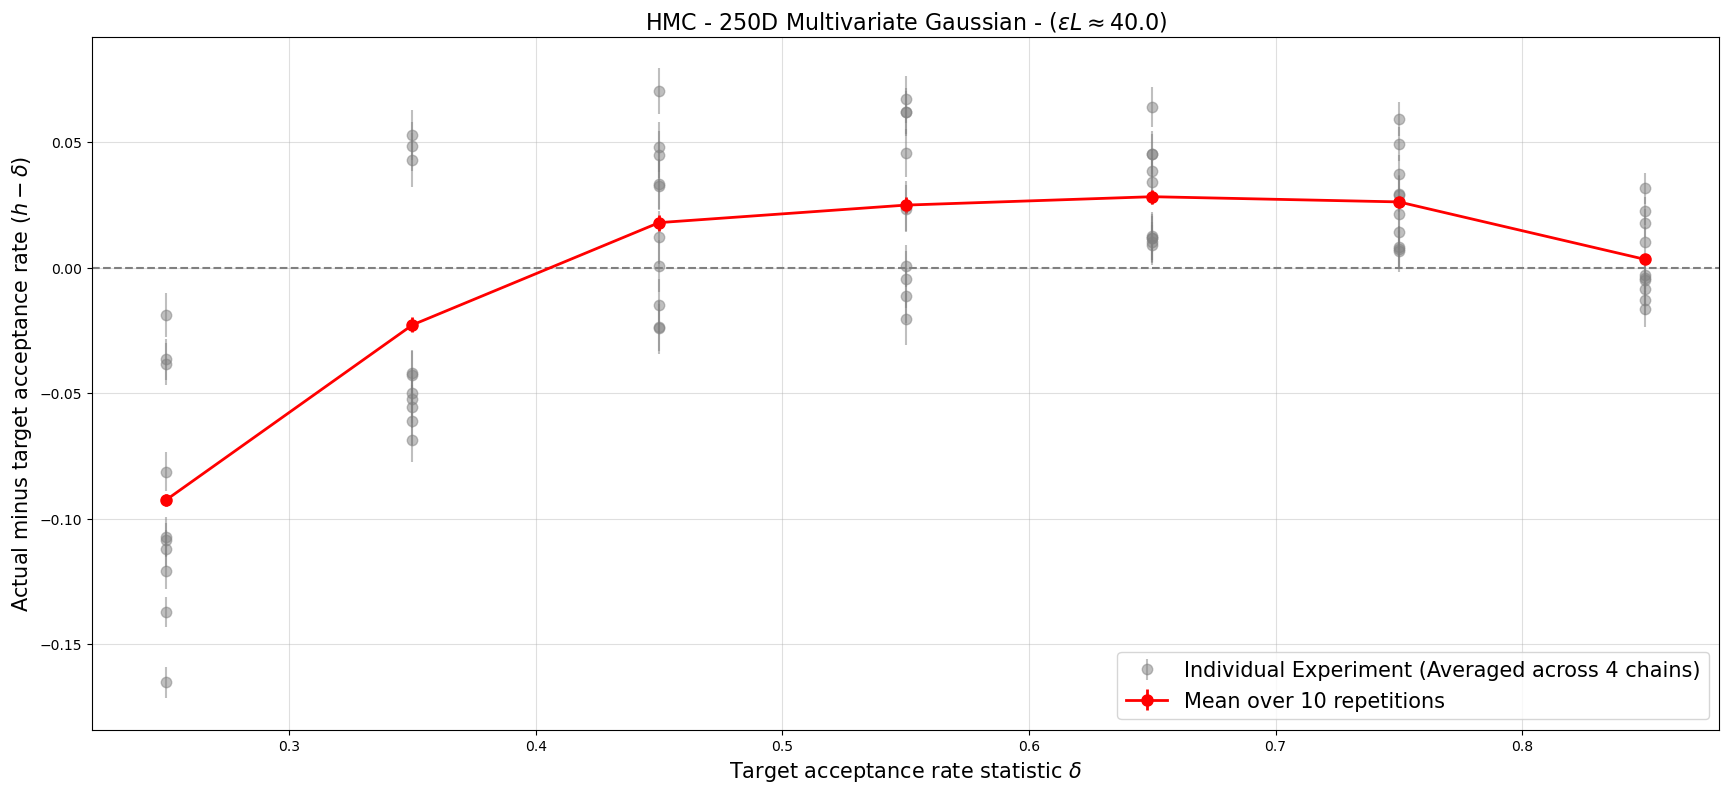

In [18]:
# Extract repetition count dynamically from your setup
reps = reps_HMC  
chains_count = sample_settings_HMC["chains"]

# Loop ONLY over the path lengths specified for the h-delta analysis.
# The union list contains extra path lengths meant only for ESS tracking which will lack full data.
for val in path_L_for_h_delta:

    # 1. Isolate the data corresponding to the current path length
    val_df = df_HMC[df_HMC["Path Length"] == val]
    
    # If a certain path length wasn't recorded or is empty, skip to prevent crashing
    if val_df.empty:
        continue

    # 2. Map the true delta list values precisely to the evaluated group indices found in the DataFrame
    x_in_graph = [delta_list_HMC[int(i)] for i in val_df["Group"].values]
    
    # Setup graph canvas
    fig, ax = plt.subplots(figsize=(21, 9))
    
    # 3. Plot the individual experiments (Averaged over 4 chains) in gray
    ax.errorbar(
        x = x_in_graph, 
        y = val_df["Diff"], 
        yerr = val_df["MCSE"], 
        ls="None", 
        marker=".", 
        ms=15, 
        label=f"Individual Experiment (Averaged across {chains_count} chains)", 
        color="gray",
        alpha = 0.5
    )
    
    # 4. Compute and plot the collective mean profile across all 10 repetitions in red
    mean_diffs = val_df.groupby(by="Group")["Diff"].mean()
    # Propagate MCSE standard errors safely for independent repeated experiments
    combined_mcse = val_df.groupby(by="Group")["MCSE"].apply(lambda x: np.sqrt((x**2).sum()) / reps)
    
    ax.errorbar(
        x = delta_list_HMC,
        y = mean_diffs,
        yerr = combined_mcse,
        ls = "-",
        marker = "o",
        ms = 8,
        label = f"Mean over {reps} repetitions",
        color="red",
        lw = 2
    )
    
    # Visual Polish & Labeling adjusted for the 250D Multivariate Gaussian Context
    plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
    plt.ylabel(r"Actual minus target acceptance rate ($h - \delta$)", fontsize=15)
    plt.title(rf"HMC - 250D Multivariate Gaussian - ($\epsilon L \approx {val:.1f}$)", fontsize=16)
    plt.legend(loc="lower right", fontsize=15)
    plt.axhline(y=0.0, ls="--", color="gray")  
    plt.grid(alpha=0.4)
    plt.show()

### ESS / Grad

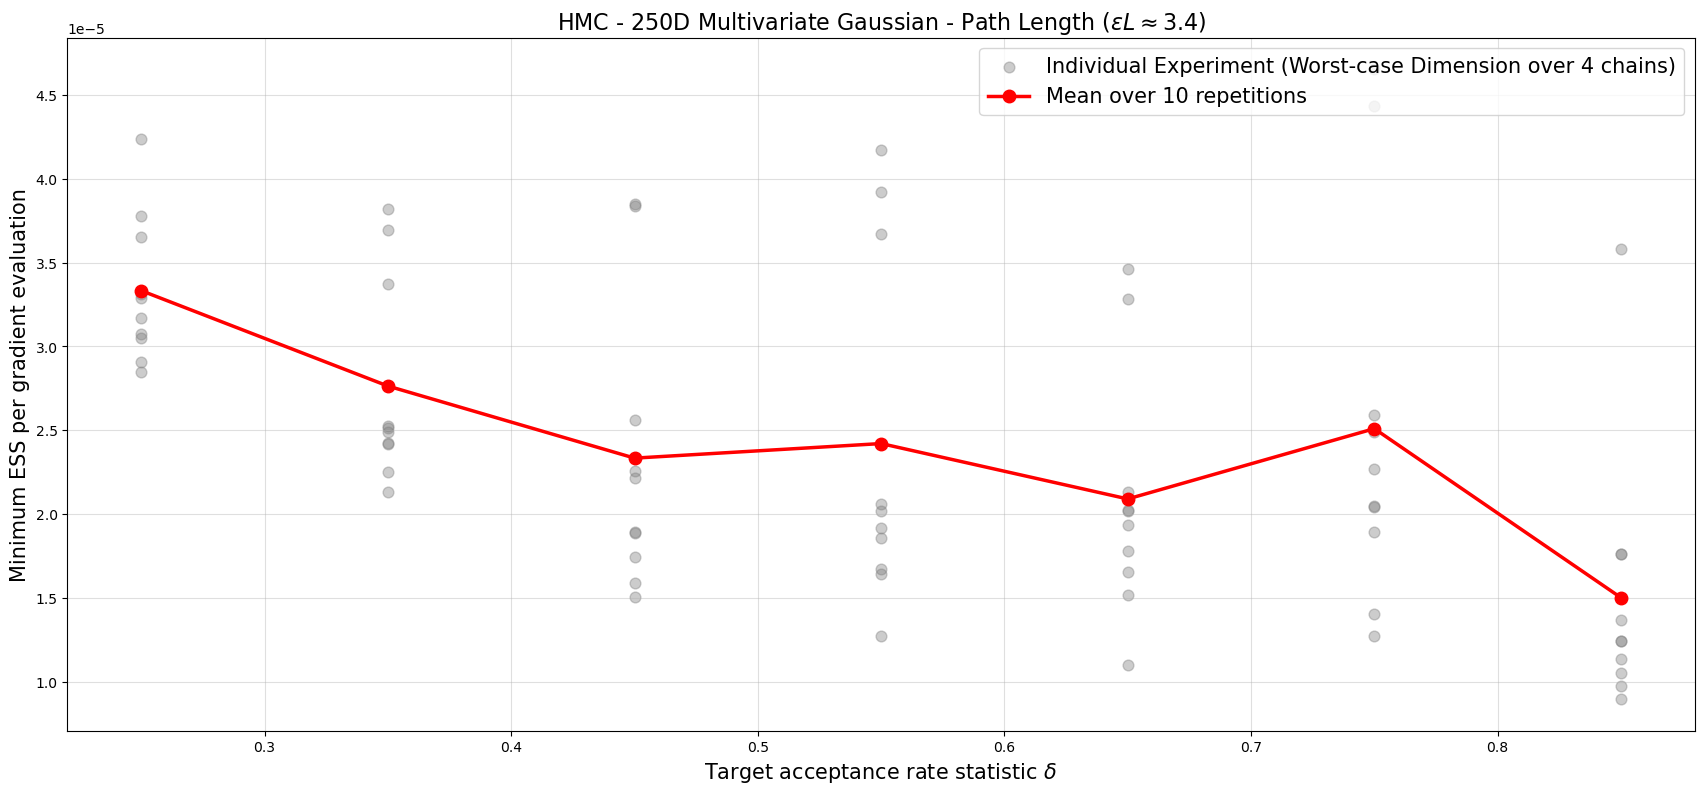

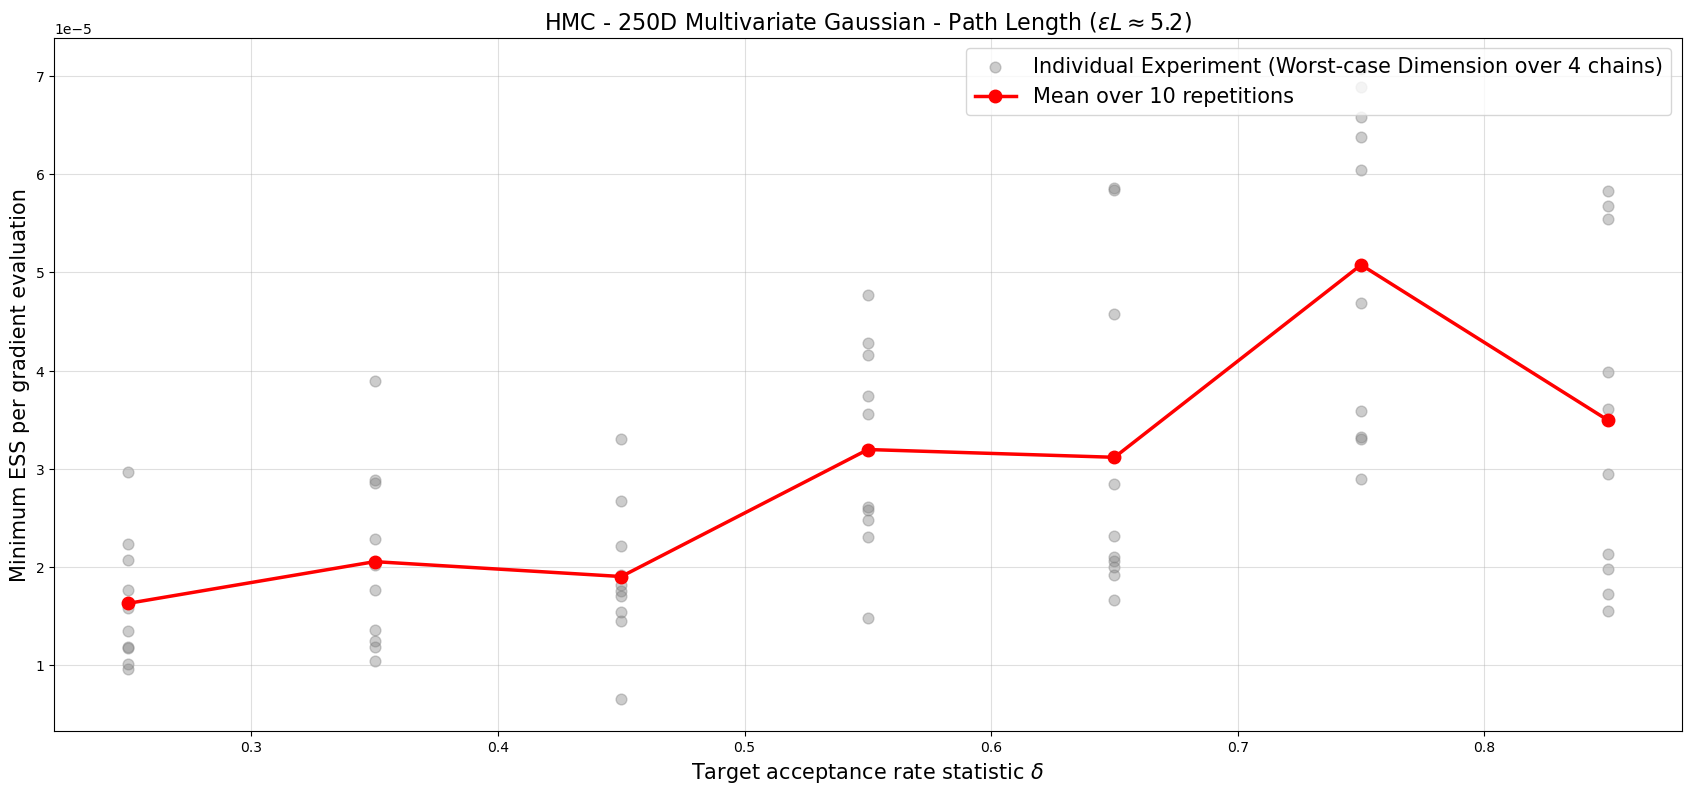

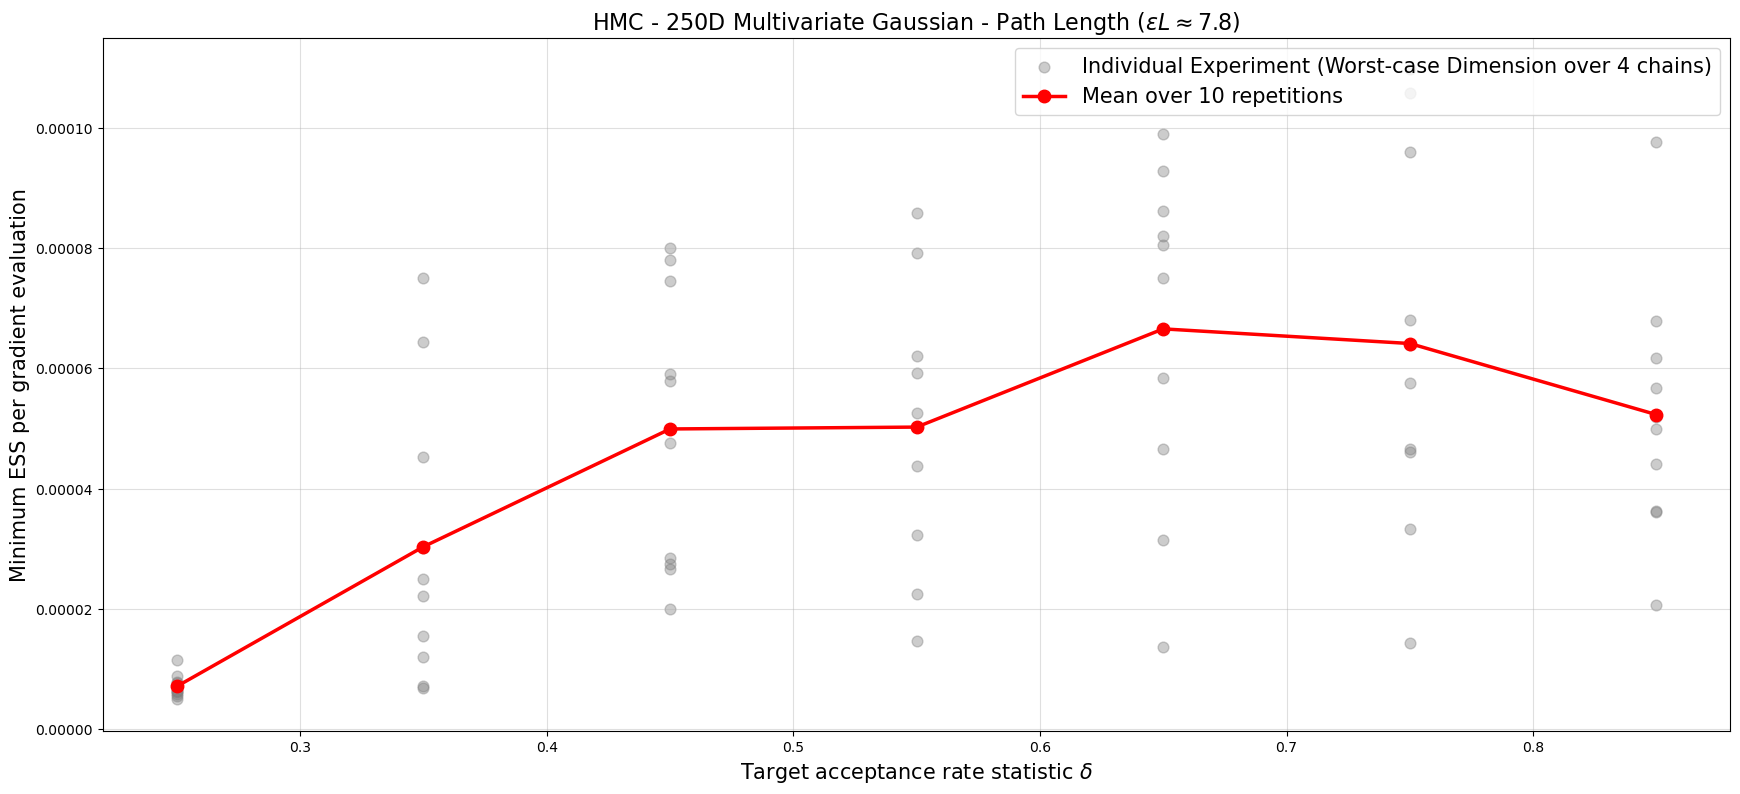

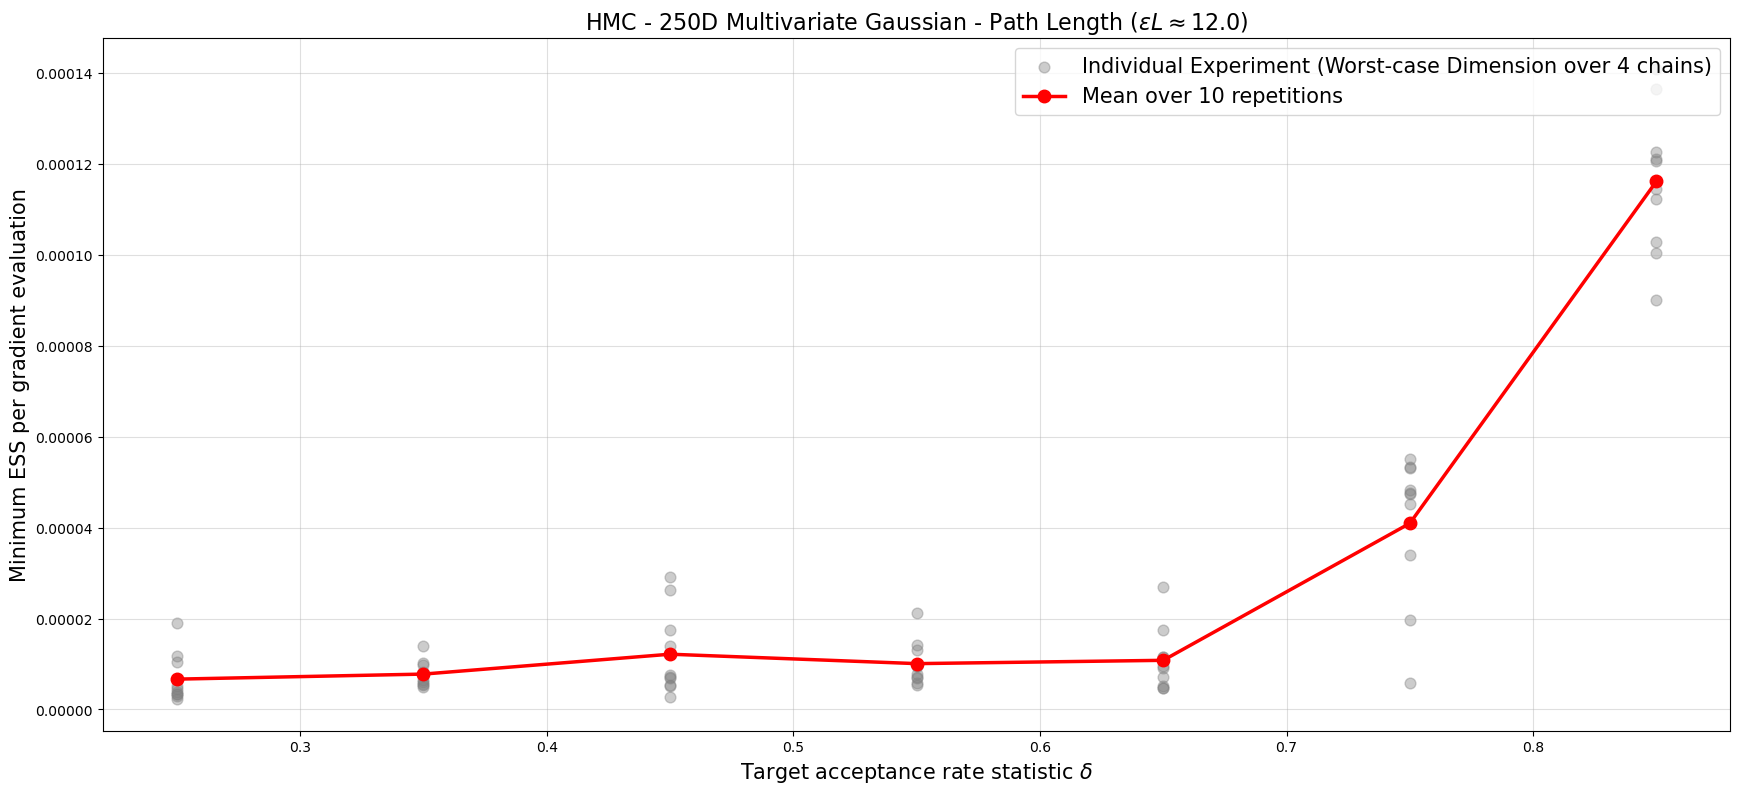

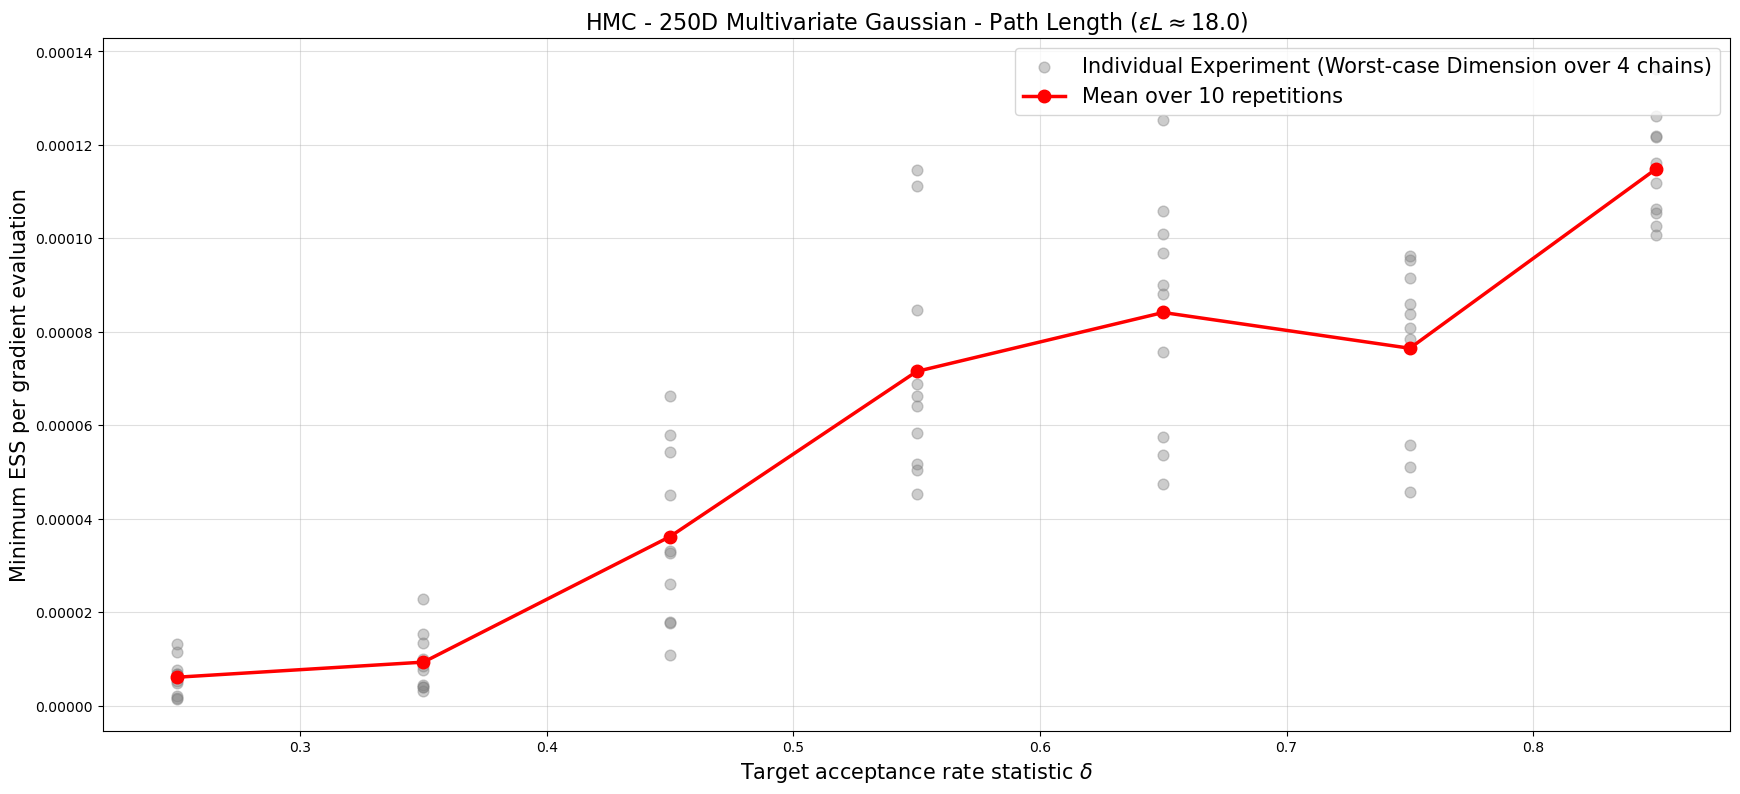

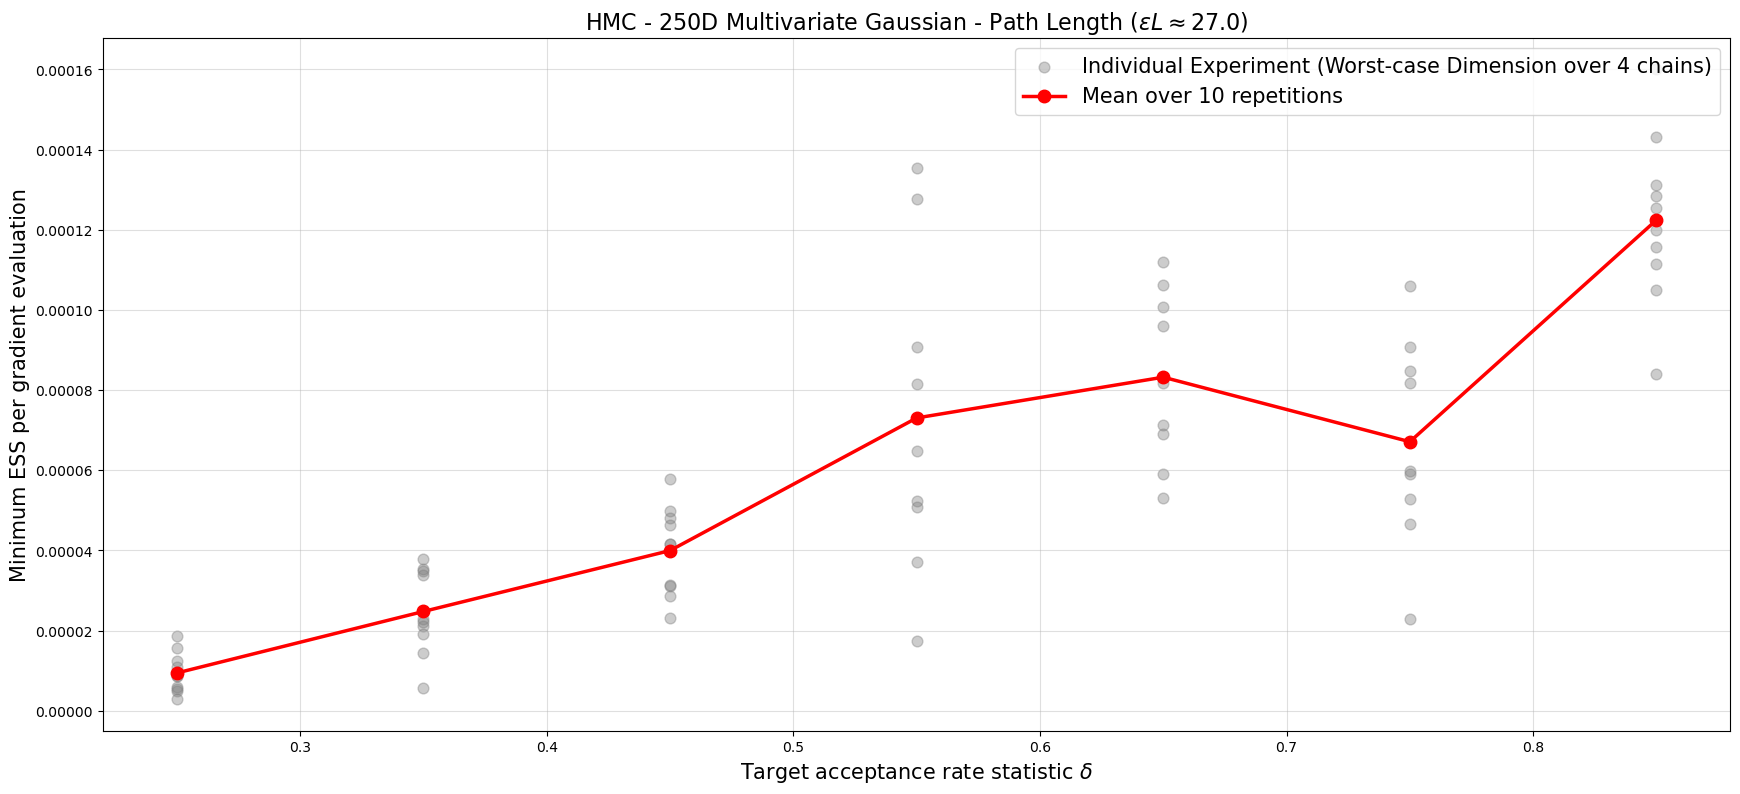

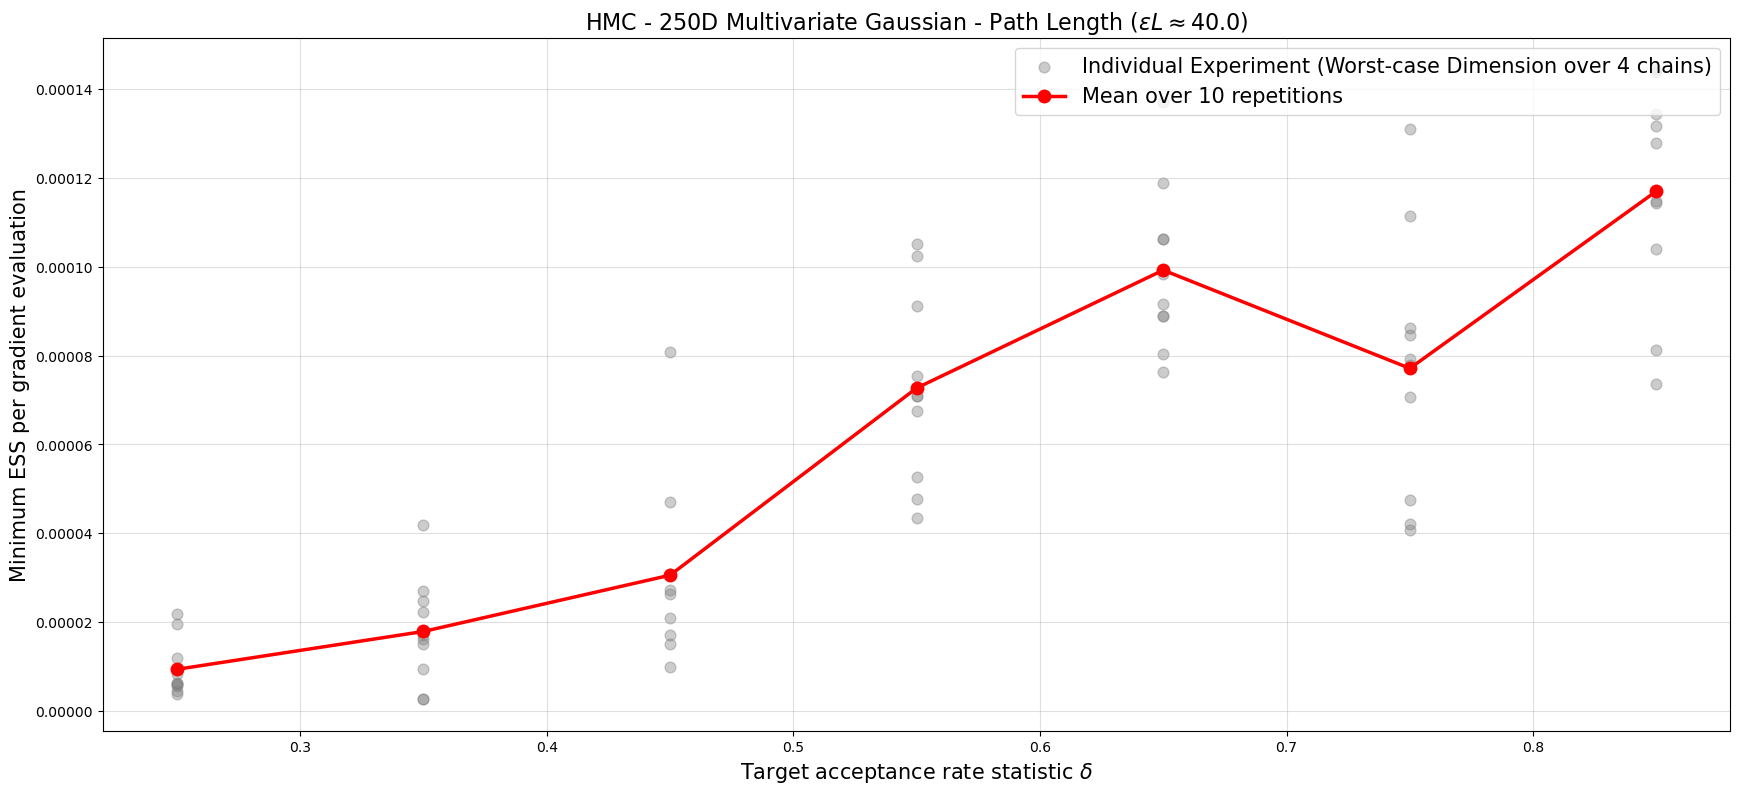

In [19]:
# Pull metrics dynamically from your setup dictionary
reps = reps_HMC  
chains_count = sample_settings_HMC["chains"]

# CRITICAL FIX 1: Loop ONLY over the path lengths designated for the ESS analysis.
# This avoids producing empty plots or inducing runtime errors for non-evaluated groups.
for val in path_L_for_ESS:

    # 1. Isolate data matching the specific path length
    val_df = df_HMC[df_HMC["Path Length"] == val]
    
    # Skip iteration safely if data frame slice is empty
    if val_df.empty:
        continue

    # 2. Re-map evaluated dataframe indices back to target delta rates
    x_in_graph = [delta_list_HMC[int(i)] for i in val_df["Group"].values]
    
    # Initialize plot canvas
    fig, ax = plt.subplots(figsize=(21, 9))
    
    # 3. Plot worst-case ESS metrics from individual runs using scatter
    ax.scatter(
        x = x_in_graph, 
        y = val_df["Min"], 
        marker = "o", 
        s = 60, 
        label = f"Individual Experiment (Worst-case Dimension over {chains_count} chains)", 
        color = "gray",
        alpha = 0.4
    )
    
    # 4. Compute and plot the mean trend line across all 10 experiments
    mean_ess_per_delta = val_df.groupby(by="Group")["Min"].mean()
    
    ax.plot(
        delta_list_HMC,
        mean_ess_per_delta,
        ls = "-",
        marker = "o",
        ms = 9,
        label = f"Mean over {reps} repetitions",
        color = "red",
        lw = 2.5
    )
    
    # Formatting and title matching your 250D Multivariate Gaussian context
    plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
    plt.ylabel("Minimum ESS per gradient evaluation", fontsize=15)
    plt.title(rf"HMC - 250D Multivariate Gaussian - Path Length ($\epsilon L \approx {val:.1f}$)", fontsize=16)
    plt.legend(loc="upper right", fontsize=15)  # Moved to upper right as ESS generally rises/peaks here
    plt.grid(alpha=0.4)
    plt.show()